# NRGPT: Energy-Based GPT Implementation Tutorial

In this coding tutorial we will go through a hands-on implementation of the concepts from the NRGPT paper, which reinterprets GPT as an energy-based dynamical system.

## Key Idea

Instead of viewing Transformer inference as a single forward pass through stacked layers, NRGPT shows that GPT can be understood as **iterative gradient descent** on a learned energy function:

$$X^{(t+1)} = X^{(t)} - \eta \nabla_X E(X^{(t)})$$

where:
- $X^{(t)}$ is the hidden state at iteration $t$
- $E(X)$ is the learned energy function
- $\eta$ is the step size (learning rate)

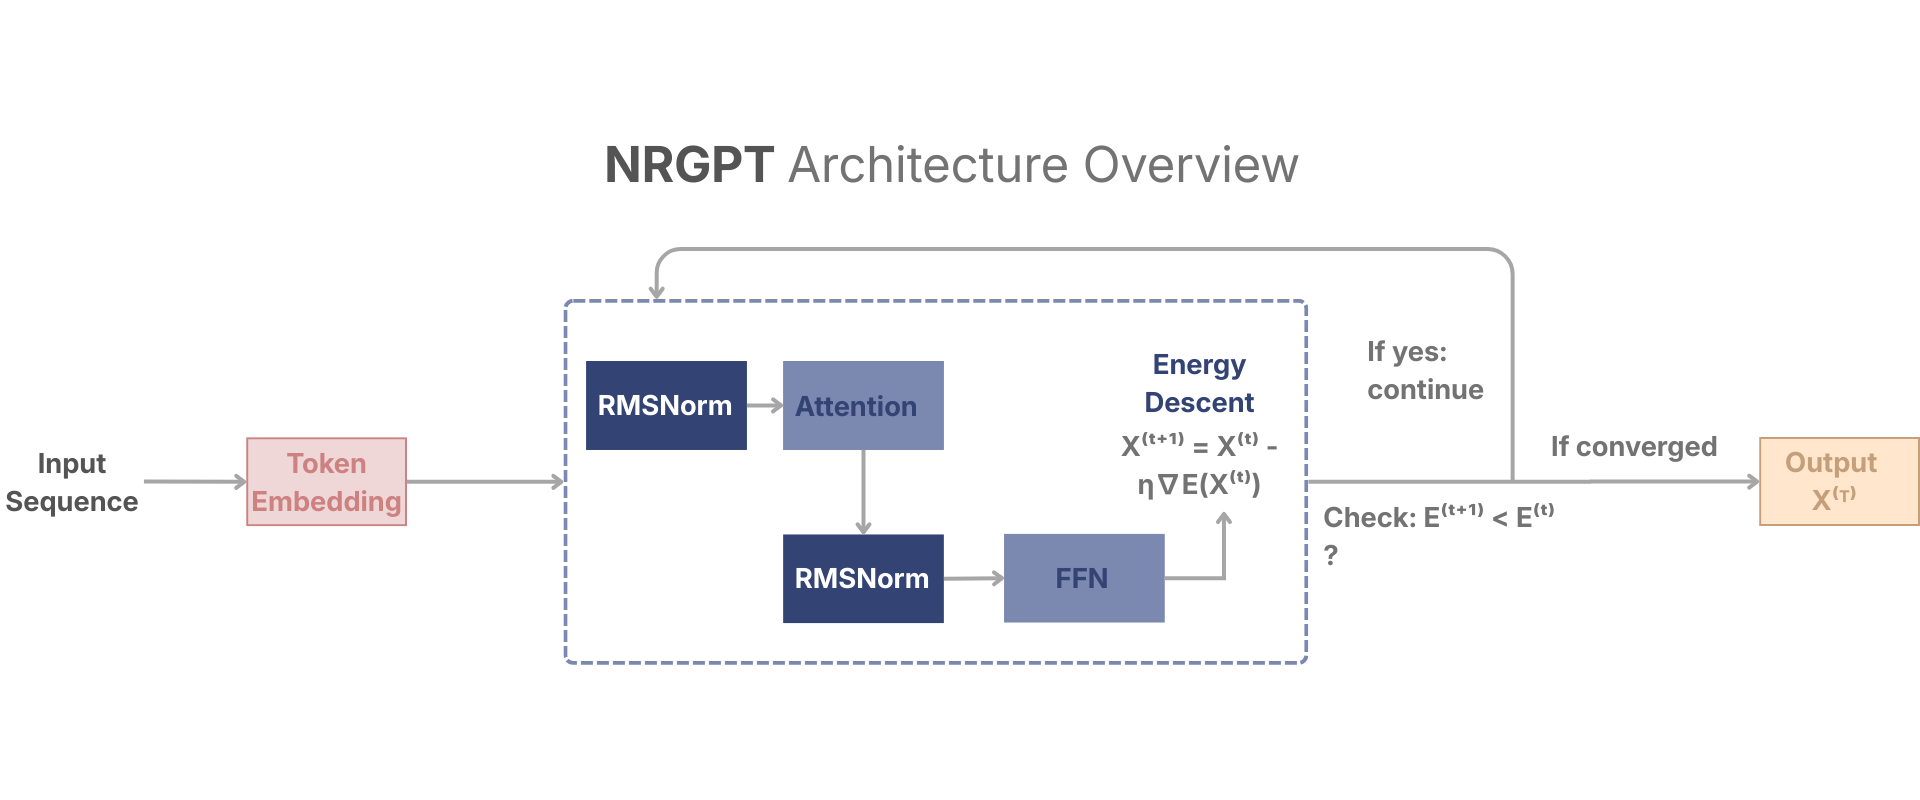

## What We'll Build

1. **Attention Energy**: Reformulates causal attention as an energy term
2. **Feed-Forward Energy**: Represents the FFN as an associative memory energy
3. **Iterative Inference**: Runs gradient descent to minimize energy
4. **Visualization**: Tracks energy convergence and stability


## Setup and Imports

We'll use PyTorch for automatic differentiation, which makes computing energy gradients straightforward.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Initialize Hidden States

We start with a batch of token embeddings $X \in \mathbb{R}^{B \times S \times D}$ where:
- $B$ = batch size
- $S$ = sequence length
- $D$ = model dimension (embedding size)

In NRGPT, these embeddings will be iteratively refined through energy minimization.


In [ ]:
# Hyperparameters
batch_size = 2
seq_len = 5
d_model = 16

# Initialize random token embeddings
# In practice, these would come from an embedding layer
X = torch.randn(batch_size, seq_len, d_model, requires_grad=True)

print(f"Hidden state shape: {X.shape}")
print(f"Gradient tracking enabled: {X.requires_grad}")

Hidden state shape: torch.Size([2, 5, 16])
Gradient tracking enabled: True


## 2. Attention Energy

### Mathematical Formulation

The attention energy is defined as:

$$E_{\text{attn}}(X) = -\sum_{i} \sum_{j < i} \langle q_i, k_j \rangle \cdot \langle x_i, x_j \rangle$$

where:
- $q_i = W_q x_i$ (query for token $i$)
- $k_j = W_k x_j$ (key for token $j$)
- The constraint $j < i$ preserves causal (autoregressive) structure


Taking the gradient $\nabla_{x_i} E_{\text{attn}}$ produces attention-like aggregation:
- Low energy when queries and keys align well
- Gradient descent naturally aggregates information from past tokens



In [ ]:
class AttentionEnergy(nn.Module):
    """Attention as an energy function.

    Computes causal attention scores and aggregates them into a scalar energy.
    The gradient of this energy w.r.t. X produces attention-like updates.
    """
    def __init__(self, d_model):
        super().__init__()
        # linear projections for queries and keys
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)

    def forward(self, X):

        # Project to queries and keys
        Q = self.Wq(X)  # (B, S, D)
        K = self.Wk(X)  # (B, S, D)

        # Compute attention scores: Q @ K^T
        scores = torch.matmul(Q, K.transpose(-1, -2))  # (B, S, S)

        # Apply causal mask (only attend to previous tokens)
        # diagonal=-1 excludes the current token (strict causality)
        mask = torch.tril(torch.ones_like(scores), diagonal=-1)
        scores = scores * mask

        # Aggregate scores into energy using softplus for smoothness
        # softplus(x) = log(1 + exp(x)) is a smooth approximation of ReLU, we use this for smooth gradients
        energy = torch.sum(F.softplus(scores))

        return energy

# Test the attention energy
attn_energy = AttentionEnergy(d_model)
E_attn = attn_energy(X)
print(f"\nAttention Energy: {E_attn}")


Attention Energy: 41.947601318359375


## 3. Feed-Forward Network Energy

### Mathematical Formulation

The FFN energy treats each token independently:

$$E_{\text{ffn}}(X) = \sum_{i} \phi(x_i)$$

where $\phi$ is a learned potential function (MLP).

This acts as an **associative memory**:
- $\phi$ learns to assign low energy to "valid" or "expected" token representations
- High energy indicates tokens that are out-of-distribution or inconsistent
- The gradient $\nabla_{x_i} \phi(x_i)$ pushes representations toward low-energy regions

The final layer outputs a scalar energy for each token.

In [ ]:
class FFNEnergy(nn.Module):
    """Feed-forward network as an energy function.
    """
    def __init__(self, d_model, hidden=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, X):

        phi = self.mlp(X)
        energy = phi.sum()
        return energy

# Test the FFN energy
ffn_energy = FFNEnergy(d_model)
E_ffn = ffn_energy(X)
print(f"FFN Energy: {E_ffn.item():.4f}")

FFN Energy: -0.5888


## 4. Combined NRGPT Energy

### Total Energy Function

The complete energy combines both components, the attention and FFN energies with normalization. During inference, gradient descent on this energy refines hidden states.

$$E(X) = E_{\text{attn}}(X) + E_{\text{ffn}}(X)$$

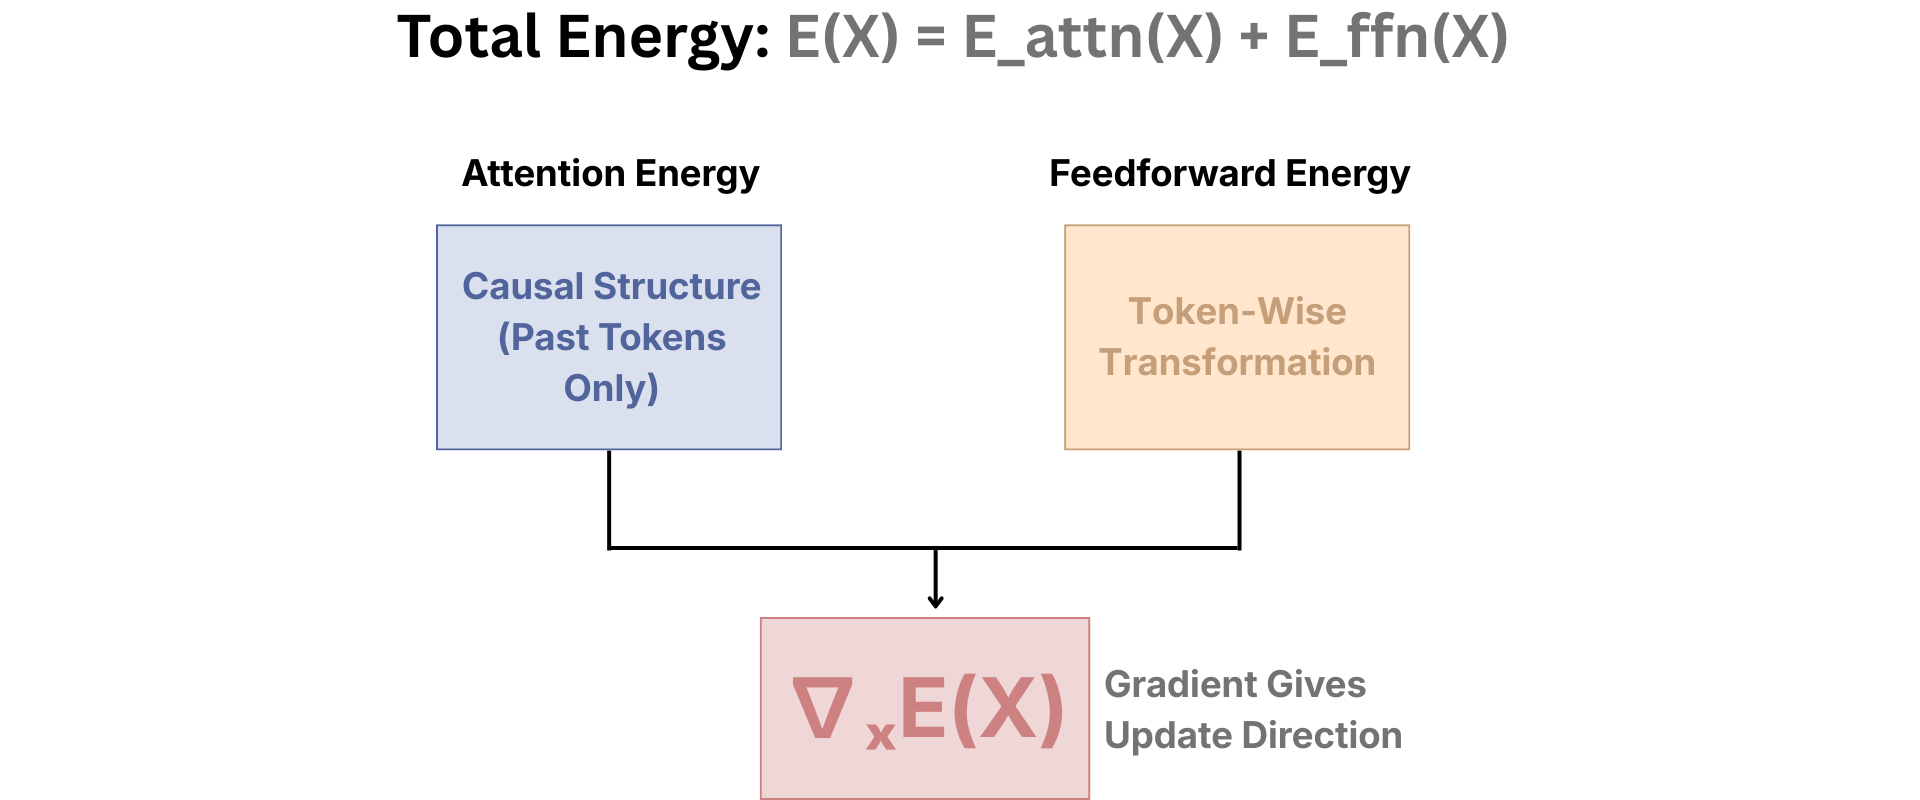

In [ ]:
class NRGPT_Energy(nn.Module):
    """Complete NRGPT energy function.
    """
    def __init__(self, d_model):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.attn_energy = AttentionEnergy(d_model)
        self.ffn_energy = FFNEnergy(d_model)

    def forward(self, X):

        # Normalize first (crucial for stability)
        Xn = self.norm(X)

        # Combine energies
        return self.attn_energy(Xn) + self.ffn_energy(Xn)

# Test the combined energy
energy_model = NRGPT_Energy(d_model)
E_total = energy_model(X)
print(f"\nTotal Energy: {E_total}")


Total Energy: 43.516971588134766


## 5. Energy-Based Inference

### The Core Algorithm

This is where NRGPT differs most dramatically from standard GPT. Instead of a single forward pass, we perform **iterative gradient descent**:

```
for t = 0 to T:
    1. Compute E(X^(t))
    2. Compute gradient: g = ∇_X E(X^(t))
    3. Update: X^(t+1) = X^(t) - α·g
```

### Key Insights

1. **Depth = Inference Steps**: Model depth is now a runtime parameter, not fixed at training
2. **Weight Sharing**: The same energy function is applied at each step (similar to recurrent networks)
3. **Adaptive Computation**: Could stop early when energy converges


In [ ]:
def nrgpt_inference(X, energy_model, steps=20, lr=0.01, grad_clip=1.0):
    """
    Perform energy-based inference via gradient descent.

    Args:
        X: Initial hidden states (batch_size, seq_len, d_model)
        energy_model: NRGPT_Energy instance
        steps: Number of gradient descent iterations
        lr: Learning rate (step size α)
        grad_clip: Maximum gradient norm (for stability)

    Returns:
        X_final: Converged hidden states
        energies: Energy at each step
        grad_norms: Gradient magnitude at each step
        state_norms: Hidden state magnitude at each step
    """
    # Tracking lists
    energies = []
    grad_norms = []
    state_norms = []

    for t in range(steps):
        # Compute energy
        energy = energy_model(X)

        # Compute gradient ∇_X E(X)
        # We use autograd.grad instead of .backward() for cleaner control
        grad = torch.autograd.grad(energy, X, create_graph=False)[0]

        # Record metrics (before update)
        energies.append(energy.item())
        grad_norms.append(grad.norm().item())
        state_norms.append(X.norm().item())

        # Gradient clipping for stability
        grad = torch.clamp(grad, -grad_clip, grad_clip)

        # Gradient descent step: X^(t+1) = X^(t) - α·∇E
        with torch.no_grad():
            X = X - lr * grad

        # Detach and re-enable gradients for next iteration
        X = X.detach().requires_grad_(True)

    return X, energies, grad_norms, state_norms

## 6. Run Inference and Analyze Convergence

Now we'll actually run the energy-based inference and observe its behavior.

### What to Expect?

According to the NRGPT paper's theoretical analysis:
- **Energy should decrease**: $E(X^{(t+1)}) \leq E(X^{(t)})$ (after initial transient)
- **Gradients should shrink**: As we approach a minimum, $\|\nabla E\| \to 0$
- **States should stabilize**: $\|X^{(t+1)} - X^{(t)}\| \to 0$

If energy increases or oscillates wildly, it suggests:
- Learning rate is too high
- The energy landscape is poorly conditioned
- Normalization is insufficient

In [ ]:
# Run inference
print("Running NRGPT inference...\n")
X_final, energies, grad_norms, state_norms = nrgpt_inference(
    X,
    energy_model,
    steps=50,
    lr=0.01
)

print(f"Initial Energy: {energies[0]:.4f}")
print(f"Final Energy: {energies[-1]:.4f}")
print(f"Energy Reduction: {energies[0] - energies[-1]:.4f}")

Running NRGPT inference...

Initial Energy: 43.5170
Final Energy: 35.1353
Energy Reduction: 8.3816


## 7. Visualization: Energy Trajectory

### Interpreting the Energy Plot

The energy curve reveals the optimization dynamics:

- Monotonic decrease (possibly after a brief transient phase)
- Smooth curve (no wild oscillations)
- Convergence to a stable plateau

Remember: Our energy model has **random untrained weights**, so we don't expect perfect convergence. The key is observing stable dynamics.

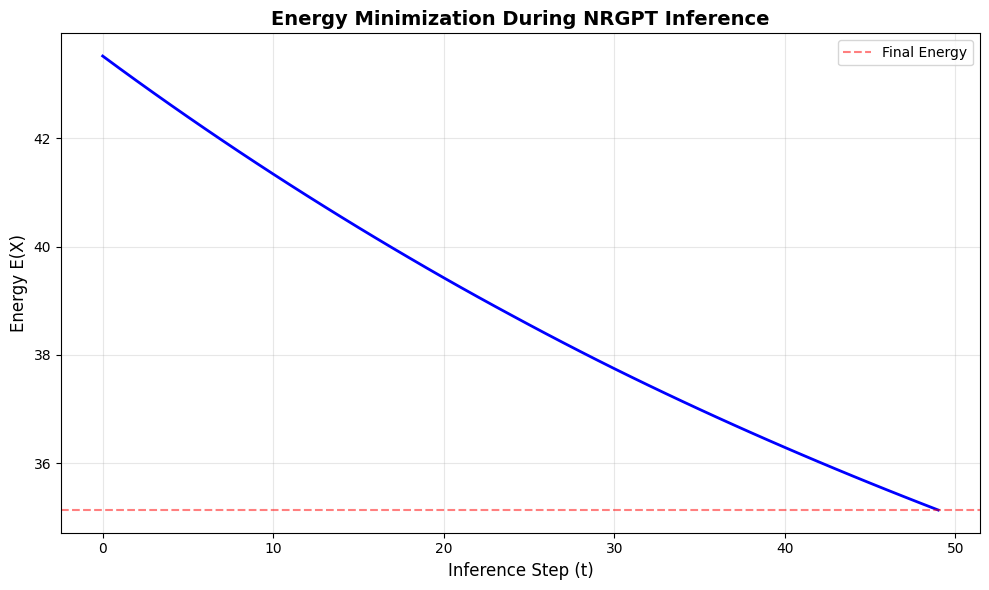

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(energies, linewidth=2, color='blue')
plt.axhline(y=energies[-1], color='red', linestyle='--', alpha=0.5, label='Final Energy')
plt.title("Energy Minimization During NRGPT Inference", fontsize=14, fontweight='bold')
plt.xlabel("Inference Step (t)", fontsize=12)
plt.ylabel("Energy E(X)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Conclusion

### What We've Demonstrated in this simple tutorial:

1. **Energy Reformulation**: GPT's forward pass can be expressed as gradient descent on an energy function
2. **Iterative Refinement**: Hidden states are refined through multiple steps, not just one forward pass
3. **Stability**: Proper normalization and gradient clipping ensure stable convergence

### NRGPT vs Standard GPT

| Aspect | Standard GPT | NRGPT |
|--------|-------------|-------|
| **Computation** | Single forward pass | Iterative optimization |
| **Depth** | Fixed (number of layers) | Adaptive (inference steps) |
| **Interpretation** | Function evaluation | Energy minimization |
| **Weights** | Different per layer | Shared across iterations |

### Implications

This energy-based view offers:
- **Theoretical tools**: Analyze stability via Lyapunov theory, energy landscapes
- **Adaptive inference**: Stop early when converged, or run longer for hard examples
- **Connections to other fields**: Links Transformers to optimization, physics, and dynamical systems
